# GI Cancer Subset — Data Analysis & Preparation
### Filtering OncoBridge's pan-cancer multi-omics data down to 7 TCGA gastrointestinal cancer types

**Source:** reuses the already-aligned, already-processed pan-cancer parquet files from the OncoBridge
pipeline (`mrna_final.parquet`, `cnv_final.parquet`, `mut_final.parquet`, `meth_final.parquet`,
`labels_final.parquet`) — no raw TCGA re-processing needed, since patient and gene alignment across
all 4 modalities was already done once for the full 32-class pan-cancer cohort.

**What this notebook does:**
1. Filters patients down to the 7 GI cancer types that actually exist as standalone TCGA cohorts
2. Merges colon adenocarcinoma + rectum adenocarcinoma into a single "colorectal cancer" class (6 final classes)
3. Runs GI-specific EDA: class balance, per-modality missingness, variance structure, quick PCA sanity check
4. Saves GI-subset parquet files for the Stage 1 training notebook

**Why merge colon + rectum:** clinically both are usually managed as "colorectal cancer"; merging also
improves class balance (357 combined vs. 273/84 split) without touching the genuinely rare class
(cholangiocarcinoma, n=36).

**GI cancers audited but NOT included:** small intestine, anal, gallbladder, GIST, GI-NETs, appendiceal,
ampullary, duodenal, jejunal, ileal cancer — none of these has a standalone multi-omics TCGA cohort at a
usable sample size.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']  = 120
plt.rcParams['font.size']   = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

def section(title):
    print('\n' + '=' * 65)
    print(f'  {title}')
    print('=' * 65)

def mem_usage(df, name):
    mb = df.memory_usage(deep=True).sum() / 1e6
    print(f'  [{name}] RAM usage: {mb:.1f} MB | shape: {df.shape}')

# =============================================================================
#  FILE PATHS — source: full pan-cancer processed data (already aligned)
#  Update SRC_BASE if your Kaggle dataset slug differs.
# =============================================================================
SRC_BASE = '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data-muationmrnacnvmethyl-idgene'

path_mrna_full  = f'{SRC_BASE}/mrna_final.parquet'
path_cnv_full   = f'{SRC_BASE}/cnv_final.parquet'
path_mut_full   = f'{SRC_BASE}/mut_final.parquet'
path_meth_full  = f'{SRC_BASE}/meth_final.parquet'
path_label_full = f'{SRC_BASE}/labels_final.parquet'

OUT_DIR = '/kaggle/working/'

# =============================================================================
#  GI CANCER TYPE MAP — TCGA _primary_disease label -> final GI class
#  Colon + Rectum merged into a single "colorectal cancer" class.
#  These 7 TCGA disease labels are the only GI cancers with multi-omics
#  coverage in the pan-cancer cohort (see notebook header for the full audit
#  against the 16 GI cancer types on the clinical list).
# =============================================================================
GI_DISEASE_MAP = {
    'esophageal carcinoma':            'esophageal carcinoma',
    'stomach adenocarcinoma':          'stomach adenocarcinoma',
    'colon adenocarcinoma':            'colorectal cancer',
    'rectum adenocarcinoma':           'colorectal cancer',
    'pancreatic adenocarcinoma':       'pancreatic adenocarcinoma',
    'liver hepatocellular carcinoma':  'liver hepatocellular carcinoma',
    'cholangiocarcinoma':              'cholangiocarcinoma',
}

GI_SOURCE_LABELS = list(GI_DISEASE_MAP.keys())
GI_FINAL_CLASSES = sorted(set(GI_DISEASE_MAP.values()))

print('Setup complete.')
print(f'Source TCGA labels used ({len(GI_SOURCE_LABELS)}):')
for lbl in GI_SOURCE_LABELS:
    print(f'  - {lbl:<32} ->  {GI_DISEASE_MAP[lbl]}')
print(f'\nFinal GI classes ({len(GI_FINAL_CLASSES)}): {GI_FINAL_CLASSES}')


Setup complete.
Source TCGA labels used (7):
  - esophageal carcinoma             ->  esophageal carcinoma
  - stomach adenocarcinoma           ->  stomach adenocarcinoma
  - colon adenocarcinoma             ->  colorectal cancer
  - rectum adenocarcinoma            ->  colorectal cancer
  - pancreatic adenocarcinoma        ->  pancreatic adenocarcinoma
  - liver hepatocellular carcinoma   ->  liver hepatocellular carcinoma
  - cholangiocarcinoma               ->  cholangiocarcinoma

Final GI classes (6): ['cholangiocarcinoma', 'colorectal cancer', 'esophageal carcinoma', 'liver hepatocellular carcinoma', 'pancreatic adenocarcinoma', 'stomach adenocarcinoma']


## Cell 2 — Load pan-cancer data & filter to GI subset

In [2]:
section('2. LOAD PAN-CANCER DATA & FILTER TO GI SUBSET')

print('Loading full pan-cancer parquet files...')
mrna_full  = pd.read_parquet(path_mrna_full)
cnv_full   = pd.read_parquet(path_cnv_full)
mut_full   = pd.read_parquet(path_mut_full)
meth_full  = pd.read_parquet(path_meth_full)
label_full = pd.read_parquet(path_label_full)

print(f'  mRNA (full pan-cancer):    {mrna_full.shape}')
print(f'  CNV  (full pan-cancer):    {cnv_full.shape}')
print(f'  Mut  (full pan-cancer):    {mut_full.shape}')
print(f'  Meth (full pan-cancer):    {meth_full.shape}')
print(f'  Labels (full pan-cancer):  {label_full.shape}')

# -- Filter to GI patients only ---------------------------------------------
label_full['_primary_disease'] = label_full['_primary_disease'].str.strip().str.lower()
gi_mask     = label_full['_primary_disease'].isin(GI_SOURCE_LABELS)
gi_patients = label_full.index[gi_mask]

print(f'\nGI patients found: {len(gi_patients):,} / {len(label_full):,} total pan-cancer patients')

mrna   = mrna_full.loc[gi_patients].copy()
cnv    = cnv_full.loc[gi_patients].copy()
mut    = mut_full.loc[gi_patients].copy()
meth   = meth_full.loc[gi_patients].copy()
labels = label_full.loc[gi_patients].copy()

# -- Apply GI class merge (colon + rectum -> colorectal cancer) -------------
labels['_gi_class'] = labels['_primary_disease'].map(GI_DISEASE_MAP)
assert labels['_gi_class'].isnull().sum() == 0, 'Unmapped disease label found -- check GI_DISEASE_MAP'

del mrna_full, cnv_full, mut_full, meth_full, label_full
gc.collect()

print('\nPost-filter shapes:')
mem_usage(mrna, 'mRNA (GI)')
mem_usage(cnv,  'CNV (GI)')
mem_usage(mut,  'Mutation (GI)')
mem_usage(meth, 'Methylation (GI)')
print(f'  [labels] shape: {labels.shape}')

print('\nOriginal TCGA label breakdown (pre-merge):')
print(labels['_primary_disease'].value_counts().to_string())



  2. LOAD PAN-CANCER DATA & FILTER TO GI SUBSET
Loading full pan-cancer parquet files...
  mRNA (full pan-cancer):    (7912, 15816)
  CNV  (full pan-cancer):    (7912, 15816)
  Mut  (full pan-cancer):    (7912, 15816)
  Meth (full pan-cancer):    (7912, 15816)
  Labels (full pan-cancer):  (7912, 1)

GI patients found: 1,457 / 7,912 total pan-cancer patients

Post-filter shapes:
  [mRNA (GI)] RAM usage: 92.3 MB | shape: (1457, 15816)
  [CNV (GI)] RAM usage: 23.1 MB | shape: (1457, 15816)
  [Mutation (GI)] RAM usage: 23.1 MB | shape: (1457, 15816)
  [Methylation (GI)] RAM usage: 92.3 MB | shape: (1457, 15816)
  [labels] shape: (1457, 2)

Original TCGA label breakdown (pre-merge):
_primary_disease
stomach adenocarcinoma            367
liver hepatocellular carcinoma    348
colon adenocarcinoma              273
esophageal carcinoma              181
pancreatic adenocarcinoma         168
rectum adenocarcinoma              84
cholangiocarcinoma                 36


## Cell 3 — Class distribution EDA (final 6 GI classes)


  3. CLASS DISTRIBUTION -- FINAL GI CLASSES


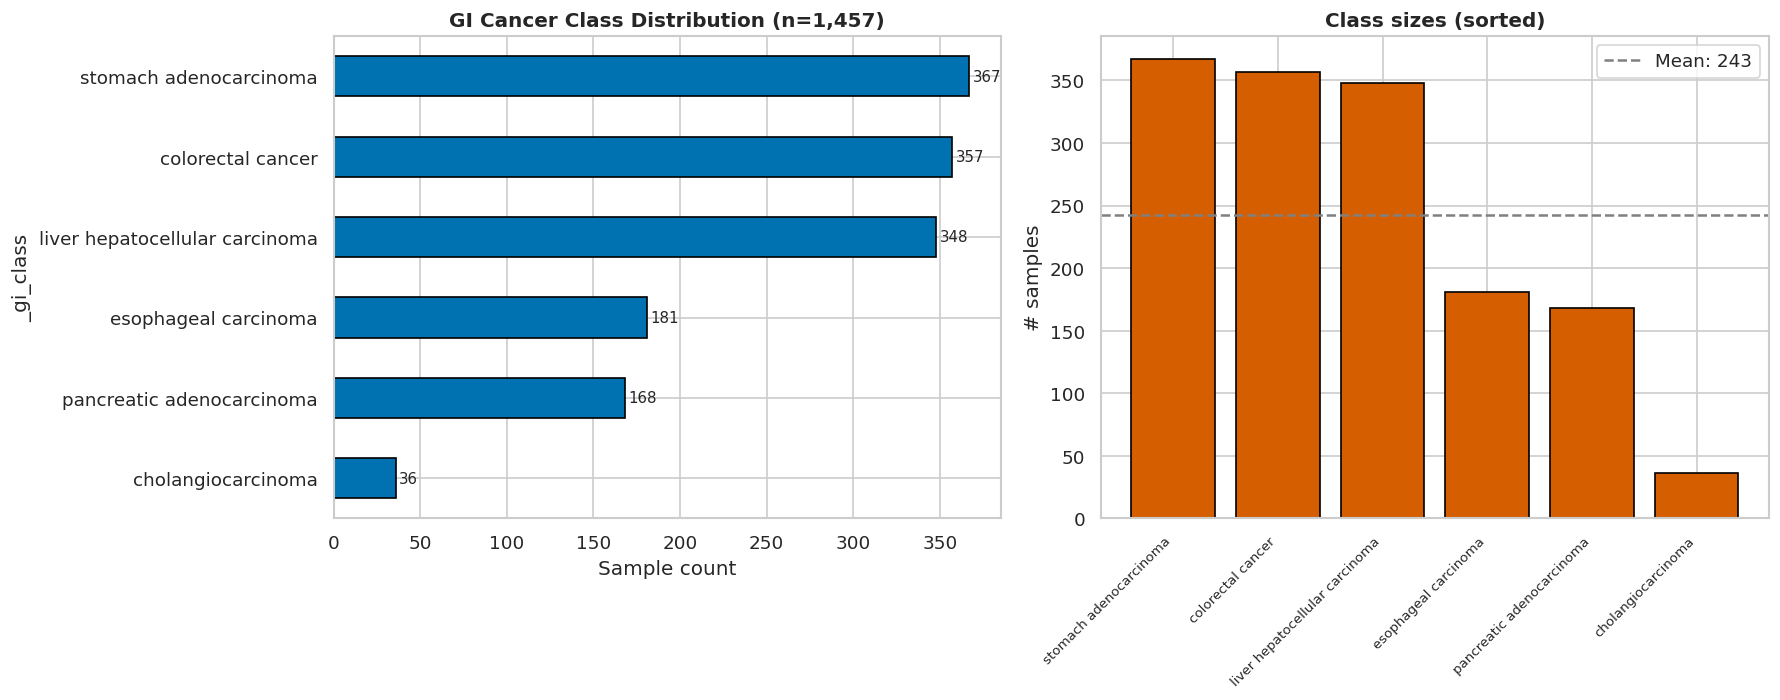


Class statistics:
  Total GI patients:  1,457
  Number of classes:  6
  Largest class:      367 (stomach adenocarcinoma)
  Smallest class:     36 (cholangiocarcinoma)
  Imbalance ratio:    10.2x

Full breakdown:
_gi_class
stomach adenocarcinoma            367
colorectal cancer                 357
liver hepatocellular carcinoma    348
esophageal carcinoma              181
pancreatic adenocarcinoma         168
cholangiocarcinoma                 36


In [3]:
section('3. CLASS DISTRIBUTION -- FINAL GI CLASSES')

class_counts = labels['_gi_class'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

class_counts.sort_values().plot(kind='barh', ax=axes[0], color='#0072B2', edgecolor='black')
axes[0].set_title(f'GI Cancer Class Distribution (n={len(labels):,})', fontweight='bold')
axes[0].set_xlabel('Sample count')
for i, val in enumerate(class_counts.sort_values().values):
    axes[0].text(val + 2, i, str(val), va='center', fontsize=9)

sorted_counts = class_counts.sort_values(ascending=False)
axes[1].bar(range(len(sorted_counts)), sorted_counts.values, color='#D55E00', edgecolor='black')
axes[1].set_xticks(range(len(sorted_counts)))
axes[1].set_xticklabels(sorted_counts.index, rotation=45, ha='right', fontsize=8)
axes[1].axhline(sorted_counts.mean(), color='gray', linestyle='--',
                label=f'Mean: {sorted_counts.mean():.0f}')
axes[1].set_title('Class sizes (sorted)', fontweight='bold')
axes[1].set_ylabel('# samples')
axes[1].legend()

plt.tight_layout()
plt.savefig('gi_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nClass statistics:')
print(f'  Total GI patients:  {len(labels):,}')
print(f'  Number of classes:  {labels["_gi_class"].nunique()}')
print(f'  Largest class:      {class_counts.max():,} ({class_counts.idxmax()})')
print(f'  Smallest class:     {class_counts.min():,} ({class_counts.idxmin()})')
print(f'  Imbalance ratio:    {class_counts.max() / class_counts.min():.1f}x')
print(f'\nFull breakdown:')
print(class_counts.sort_values(ascending=False).to_string())


## Cell 4 — Per-modality missingness & variance EDA (GI subset)


  4. PER-MODALITY MISSINGNESS & VARIANCE (GI SUBSET)
  [mRNA        ] shape=(1457, 15816) | NaN%=0.000%
  [CNV         ] shape=(1457, 15816) | NaN%=0.000%
  [Mutation    ] shape=(1457, 15816) | NaN%=0.000%
  [Methylation ] shape=(1457, 15816) | NaN%=0.000%

Top 10 most variable mRNA genes within the GI subset:
ALB      64.213730
APOA2    53.767376
FGG      46.277596
APOC3    44.870926
FGA      44.015282
HP       43.160820
GC       41.837765
FGB      41.825943
APOA1    40.573051
APOB     40.330299


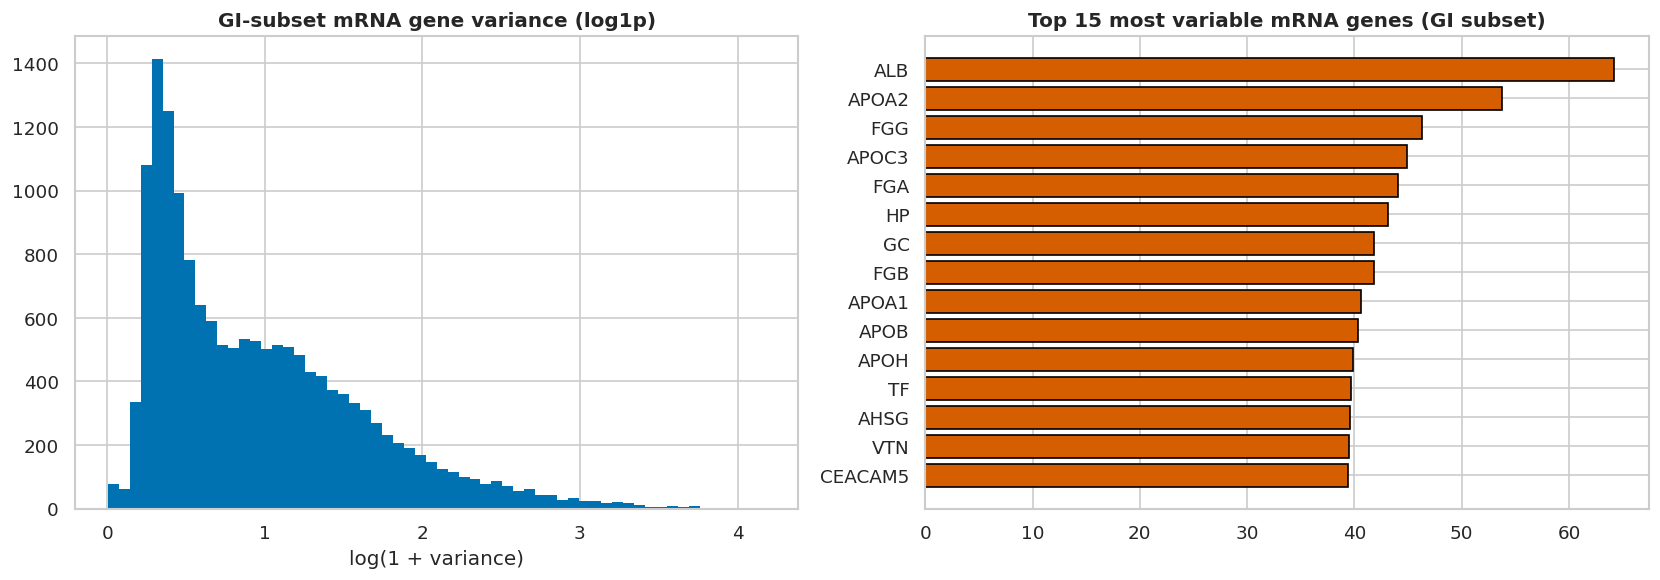

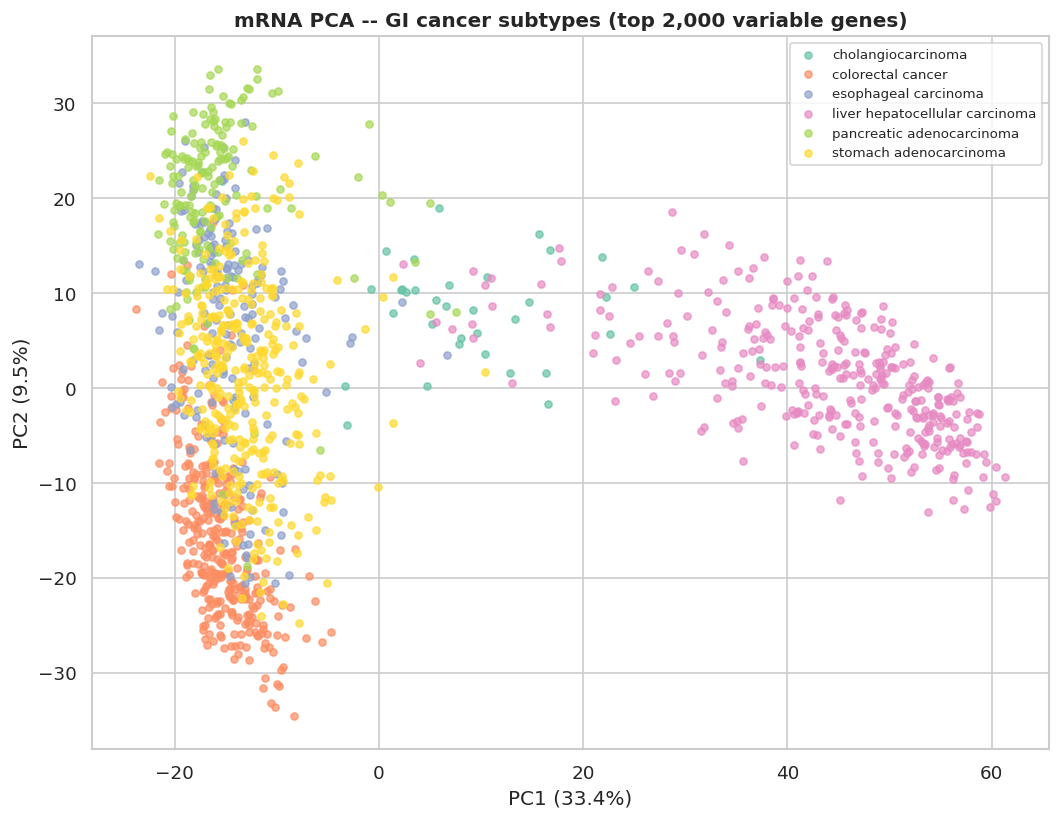

6967

In [4]:
section('4. PER-MODALITY MISSINGNESS & VARIANCE (GI SUBSET)')

for name, df in [('mRNA', mrna), ('CNV', cnv), ('Mutation', mut), ('Methylation', meth)]:
    nan_pct = df.isnull().values.mean() * 100
    print(f'  [{name:12s}] shape={df.shape} | NaN%={nan_pct:.3f}%')

# -- mRNA variance computed on the GI subset only (may re-rank vs pan-cancer) --
mrna_var_gi = mrna.var(axis=0).sort_values(ascending=False)
print(f'\nTop 10 most variable mRNA genes within the GI subset:')
print(mrna_var_gi.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(np.log1p(mrna_var_gi.values), bins=60, color='#0072B2', edgecolor='none')
axes[0].set_title('GI-subset mRNA gene variance (log1p)', fontweight='bold')
axes[0].set_xlabel('log(1 + variance)')

top15 = mrna_var_gi.head(15)
axes[1].barh(top15.index, top15.values, color='#D55E00', edgecolor='black')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 most variable mRNA genes (GI subset)', fontweight='bold')

plt.tight_layout()
plt.savefig('gi_mrna_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# -- Quick PCA sanity check: do GI classes separate in mRNA space? ----------
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

top_var_genes = mrna_var_gi.head(2000).index
mrna_pca_input = mrna[top_var_genes].fillna(mrna[top_var_genes].mean())
mrna_scaled = StandardScaler().fit_transform(mrna_pca_input)
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(mrna_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
classes_sorted = sorted(labels['_gi_class'].unique())
palette = sns.color_palette('Set2', n_colors=len(classes_sorted))
for cls, color in zip(classes_sorted, palette):
    m = labels['_gi_class'].values == cls
    ax.scatter(pcs[m, 0], pcs[m, 1], label=cls, s=18, alpha=0.7, color=color)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('mRNA PCA -- GI cancer subtypes (top 2,000 variable genes)', fontweight='bold')
ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.savefig('gi_mrna_pca.png', dpi=150, bbox_inches='tight')
plt.show()

del mrna_pca_input, mrna_scaled, pcs
gc.collect()


## Cell 5 — Save GI-subset parquet files

In [5]:
section('5. SAVING GI-SUBSET OUTPUT FILES')

# Final labels file keeps both the original TCGA label and the merged GI class
labels_out = labels[['_primary_disease', '_gi_class']].copy()
labels_out.columns = labels_out.columns.astype(str)

mrna.columns = mrna.columns.astype(str)
cnv.columns  = cnv.columns.astype(str)
mut.columns  = mut.columns.astype(str)
meth.columns = meth.columns.astype(str)

mrna.to_parquet(f'{OUT_DIR}mrna_gi.parquet');         print('  mrna_gi.parquet     saved')
cnv.to_parquet(f'{OUT_DIR}cnv_gi.parquet');           print('  cnv_gi.parquet      saved')
mut.to_parquet(f'{OUT_DIR}mut_gi.parquet');           print('  mut_gi.parquet      saved')
meth.to_parquet(f'{OUT_DIR}meth_gi.parquet');         print('  meth_gi.parquet     saved')
labels_out.to_parquet(f'{OUT_DIR}labels_gi.parquet'); print('  labels_gi.parquet   saved')

print('\n--- Summary ---')
print(f'  mrna_gi.parquet    -- {mrna.shape[0]:,} patients x {mrna.shape[1]:,} genes')
print(f'  cnv_gi.parquet     -- {cnv.shape[0]:,} patients x {cnv.shape[1]:,} genes')
print(f'  mut_gi.parquet     -- {mut.shape[0]:,} patients x {mut.shape[1]:,} genes')
print(f'  meth_gi.parquet    -- {meth.shape[0]:,} patients x {meth.shape[1]:,} genes')
print(f'  labels_gi.parquet  -- {labels_out.shape[0]:,} patients x 2 columns '
      f'(_primary_disease, _gi_class)')
print(f'\n  Final GI classes ({labels_out["_gi_class"].nunique()}): '
      f'{sorted(labels_out["_gi_class"].unique())}')

print('''
--- How to load in the Stage 1 training notebook ---
  import pandas as pd
  mrna   = pd.read_parquet("mrna_gi.parquet")
  cnv    = pd.read_parquet("cnv_gi.parquet")
  mut    = pd.read_parquet("mut_gi.parquet")
  meth   = pd.read_parquet("meth_gi.parquet")
  labels = pd.read_parquet("labels_gi.parquet")   # use labels["_gi_class"] as the target
  # All matrices are patient-aligned -- same row order guaranteed.
''')

print('\nGI data preparation complete. Upload these 5 files as a new Kaggle dataset')
print('and point the Stage 1 training notebook CONFIG paths at it.')



  5. SAVING GI-SUBSET OUTPUT FILES
  mrna_gi.parquet     saved
  cnv_gi.parquet      saved
  mut_gi.parquet      saved
  meth_gi.parquet     saved
  labels_gi.parquet   saved

--- Summary ---
  mrna_gi.parquet    -- 1,457 patients x 15,816 genes
  cnv_gi.parquet     -- 1,457 patients x 15,816 genes
  mut_gi.parquet     -- 1,457 patients x 15,816 genes
  meth_gi.parquet    -- 1,457 patients x 15,816 genes
  labels_gi.parquet  -- 1,457 patients x 2 columns (_primary_disease, _gi_class)

  Final GI classes (6): ['cholangiocarcinoma', 'colorectal cancer', 'esophageal carcinoma', 'liver hepatocellular carcinoma', 'pancreatic adenocarcinoma', 'stomach adenocarcinoma']

--- How to load in the Stage 1 training notebook ---
  import pandas as pd
  mrna   = pd.read_parquet("mrna_gi.parquet")
  cnv    = pd.read_parquet("cnv_gi.parquet")
  mut    = pd.read_parquet("mut_gi.parquet")
  meth   = pd.read_parquet("meth_gi.parquet")
  labels = pd.read_parquet("labels_gi.parquet")   # use labels["_gi_cl